In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# 创建目标文件夹
output_dir = "FNSPID_data"
os.makedirs(output_dir, exist_ok=True)

# 读取原始数据
print("正在读取 All_external.csv...")
df = pd.read_csv("All_external.csv")
print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")

# 查看数据基本信息
print(f"\n数据基本信息:")
print(f"总样本数: {len(df)}")


正在读取 All_external.csv...


C:\Users\Xinny\AppData\Local\Temp\ipykernel_26056\1996143624.py:11: DtypeWarning: Columns (2,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("All_external.csv")


原始数据形状: (13057514, 11)
列名: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

数据基本信息:
总样本数: 13057514


In [2]:

# 分割数据: 先分出训练集(70%)，剩余30%作为临时集
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    random_state=42, 
    stratify=df.get('sentiment', None) if 'sentiment' in df.columns else None
)

# 再将临时集分成验证集(15%)和测试集(15%)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42,
    stratify=temp_df.get('sentiment', None) if 'sentiment' in temp_df.columns else None
)

# 保存文件
train_path = os.path.join(output_dir, "train.csv")
val_path = os.path.join(output_dir, "validation.csv")
test_path = os.path.join(output_dir, "test.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

# 输出统计信息
print(f"\n数据分割完成!")
print(f"训练集: {len(train_df)} 条 -> {train_path}")
print(f"验证集: {len(val_df)} 条 -> {val_path}")
print(f"测试集: {len(test_df)} 条 -> {test_path}")

# 显示每个数据集的标签分布(如果有标签列)
if 'sentiment' in df.columns:
    print(f"\n训练集标签分布:")
    print(train_df['sentiment'].value_counts())
    print(f"\n验证集标签分布:")
    print(val_df['sentiment'].value_counts())
    print(f"\n测试集标签分布:")
    print(test_df['sentiment'].value_counts())

# 显示前几行数据预览
print(f"\n数据预览:")
print(f"列名: {df.columns.tolist()}")
print(f"\n前3行数据:")
print(df.head(3))

# 可选：显示文件保存路径的完整信息
print(f"\n文件已保存到: {os.path.abspath(output_dir)}")
print(f"文件列表: {os.listdir(output_dir)}")


数据分割完成!
训练集: 9140259 条 -> FNSPID_data\train.csv
验证集: 1958627 条 -> FNSPID_data\validation.csv
测试集: 1958628 条 -> FNSPID_data\test.csv

数据预览:
列名: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

前3行数据:
                      Date                               Article_title  \
0  2020-06-05 06:30:54 UTC     Stocks That Hit 52-Week Highs On Friday   
1  2020-06-03 06:45:20 UTC  Stocks That Hit 52-Week Highs On Wednesday   
2  2020-05-26 00:30:07 UTC               71 Biggest Movers From Friday   

  Stock_symbol                                                Url  \
0            A  https://www.benzinga.com/news/20/06/16190091/s...   
1            A  https://www.benzinga.com/news/20/06/16170189/s...   
2            A  https://www.benzinga.com/news/20/05/16103463/7...   

           Publisher Author Article  Lsa_summary  Luhn_summary  \
0  Benzinga Insights    NaN     NaN          NaN       

In [4]:
import random
def extract_test_samples_simple(test_file_path, output_path=None, n_samples=1000, random_seed=42):
    """
    简化版：直接读取全部测试集并随机抽样（适合内存充足的情况）
    
    参数:
        test_file_path (str): 测试集文件路径
        output_path (str): 输出文件路径（可选）
        n_samples (int): 抽取样本数量，默认1000
        random_seed (int): 随机种子，默认42
    
    返回:
        pd.DataFrame: 抽取的样本数据框
        str: 保存的文件路径
    """
    
    # 设置随机种子
    random.seed(random_seed)
    
    # 检查文件是否存在
    if not os.path.exists(test_file_path):
        raise FileNotFoundError(f"文件不存在: {test_file_path}")
    
    print(f"正在读取测试集: {test_file_path}")
    
    # 读取全部数据
    df = pd.read_csv(test_file_path)
    print(f"读取完成，总样本数: {len(df):,}")
    
    # 检查请求样本数
    if n_samples > len(df):
        print(f"警告: 请求抽取 {n_samples} 条，但测试集只有 {len(df)} 条")
        print(f"将使用全部 {len(df)} 条数据")
        n_samples = len(df)
    
    # 随机抽取
    print(f"正在随机抽取 {n_samples} 条样本...")
    sampled_df = df.sample(n=n_samples, random_state=random_seed).reset_index(drop=True)
    
    # 生成输出路径
    if output_path is None:
        base_dir = os.path.dirname(test_file_path)
        base_name = os.path.splitext(os.path.basename(test_file_path))[0]
        output_path = os.path.join(base_dir, f"{base_name}_sample_{n_samples}.csv")
    
    # 保存文件
    sampled_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ 抽取完成!")
    print(f"   抽取样本数: {len(sampled_df)}")
    print(f"   保存路径: {output_path}")
    print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")
    
    # 显示数据预览
    print(f"\n数据预览:")
    print(f"列名: {sampled_df.columns.tolist()}")
    print(f"\n前3行:")
    print(sampled_df.head(3))
    
    # 显示标签分布（如果有标签列）
    if 'Stock_symbol' in sampled_df.columns:
        print(f"\n股票代码分布 (Top 10):")
        print(sampled_df['Stock_symbol'].value_counts().head(10))
    
    if 'Lsa_summary' in sampled_df.columns:
        print(f"\n文本摘要统计:")
        print(f"   空值数量: {sampled_df['Lsa_summary'].isna().sum()}")
        print(f"   有效文本: {sampled_df['Lsa_summary'].notna().sum()}")
    
    return sampled_df, output_path


In [5]:
test_file = "FNSPID_data/test.csv"

# 方法1：简化版（推荐，内存充足时使用）
print("="*60)
print("方法1：简化版抽取")
print("="*60)
sampled_data, saved_path = extract_test_samples_simple(
    test_file_path=test_file,
    n_samples=1000,
    random_seed=42
)

方法1：简化版抽取
正在读取测试集: FNSPID_data/test.csv
读取完成，总样本数: 1,958,628
正在随机抽取 1000 条样本...

✅ 抽取完成!
   抽取样本数: 1000
   保存路径: FNSPID_data\test_sample_1000.csv
   文件大小: 0.41 MB

数据预览:
列名: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

前3行:
                      Date                                      Article_title  \
0  2013-07-22 00:00:00 UTC  Mobistar Slumps Most Since IPO on Lower Outloo...   
1  2016-04-10 07:00:00 UTC  Panama law firm says it hasn't been approached...   
2  2008-12-03 06:30:00 UTC                        Following Is a Test Release   

  Stock_symbol                                                Url Publisher  \
0          NaN  http://www.bloomberg.com/news/2013-07-22/mobis...       NaN   
1          NaN  http://www.reuters.com/article/panama-tax-fons...       NaN   
2          NaN  http://www.reuters.com/article/pressRelease/id...       NaN   

                         

In [6]:
import pandas as pd

# 读取抽取的样本（或直接读取一小部分测试集）
test_sample = pd.read_csv("FNSPID_data/test.csv", nrows=100)

# 检查各列的非空情况
print("各列非空数据统计:")
print("="*60)
for col in test_sample.columns:
    non_null_count = test_sample[col].notna().sum()
    non_null_percent = (non_null_count / len(test_sample)) * 100
    print(f"{col:20} : {non_null_count:5} 条非空 ({non_null_percent:.1f}%)")

# 查看实际数据内容
print("\n" + "="*60)
print("前3行实际数据:")
print(test_sample[['Stock_symbol', 'Article_title', 'Article', 'Lsa_summary', 'Luhn_summary']].head(3))

# 查看有数据的列
print("\n" + "="*60)
print("有数据的列:")
data_cols = []
for col in test_sample.columns:
    if test_sample[col].notna().sum() > 0:
        data_cols.append(col)
        print(f"  ✓ {col}")

print(f"\n建议使用的文本列: {data_cols}")

各列非空数据统计:
Date                 :   100 条非空 (100.0%)
Article_title        :   100 条非空 (100.0%)
Stock_symbol         :    24 条非空 (24.0%)
Url                  :   100 条非空 (100.0%)
Publisher            :    26 条非空 (26.0%)
Author               :     5 条非空 (5.0%)
Article              :     5 条非空 (5.0%)
Lsa_summary          :     0 条非空 (0.0%)
Luhn_summary         :     0 条非空 (0.0%)
Textrank_summary     :     0 条非空 (0.0%)
Lexrank_summary      :     0 条非空 (0.0%)

前3行实际数据:
  Stock_symbol                                      Article_title Article  \
0          NaN  Christina Applegate kept cancer diagnosis a se...     NaN   
1          NaN  D2's mCUE Completes Successful MSF Interoperab...     NaN   
2          NaN  Xella puts stock listing on ice on market vola...     NaN   

   Lsa_summary  Luhn_summary  
0          NaN           NaN  
1          NaN           NaN  
2          NaN           NaN  

有数据的列:
  ✓ Date
  ✓ Article_title
  ✓ Stock_symbol
  ✓ Url
  ✓ Publisher
  ✓ Author
  ✓ Article

建

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os

def extract_and_predict():
    """
    从测试集抽取1000条有效样本并进行FinBERT预测
    """
    
    print("="*60)
    print("Step 1: 读取测试集并抽取样本")
    print("="*60)
    
    # 读取测试集（只读取需要的列以节省内存）
    usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']
    
    print("正在读取测试集...")
    df = pd.read_csv("FNSPID_data/test.csv", usecols=usecols)
    print(f"总样本数: {len(df):,}")
    
    # 过滤出有标题的行（所有行都有，但确保安全）
    valid_df = df[df['Article_title'].notna()].copy()
    print(f"有效样本数: {len(valid_df):,}")
    
    # 随机抽取1000条
    sample_size = 1000
    sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f"抽取样本数: {len(sampled_df)}")
    
    # 保存抽取的样本
    sample_path = "FNSPID_data/test_sample_1000.csv"
    sampled_df.to_csv(sample_path, index=False)
    print(f"样本已保存到: {sample_path}")
    
    print("\n" + "="*60)
    print("Step 2: 加载 FinBERT 模型")
    print("="*60)
    
    # 加载模型
    model_name = "yiyanghkust/finbert-tone"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    
    # 使用GPU（如果可用）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    print(f"使用设备: {device}")
    
    print("\n" + "="*60)
    print("Step 3: 批量预测情感")
    print("="*60)
    
    # 准备文本
    texts = sampled_df['Article_title'].fillna('').tolist()
    
    # 批量预测
    batch_size = 64
    results = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
        batch_texts = texts[i:i+batch_size]
        
        # 编码
        inputs = tokenizer(batch_texts, return_tensors="pt", 
                          truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 预测
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
        
        # 解析结果
        for j, prob in enumerate(probs):
            neg = prob[0].item()
            neu = prob[1].item()
            pos = prob[2].item()
            score = pos - neg  # 情感分数 -1 到 1
            
            # 分类标签（阈值可调整）
            if score > 0.2:
                label = "positive"
            elif score < -0.2:
                label = "negative"
            else:
                label = "neutral"
            
            results.append({
                'sentiment_score': score,
                'predicted_label': label,
                'negative_prob': neg,
                'neutral_prob': neu,
                'positive_prob': pos
            })
    
    # 合并结果
    result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)
    
    print("\n" + "="*60)
    print("Step 4: 结果分析")
    print("="*60)
    
    # 统计分析
    print(f"\n情感分数统计:")
    print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
    print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
    print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
    print(f"  最大值: {result_df['sentiment_score'].max():.4f}")
    
    print(f"\n情感标签分布:")
    label_counts = result_df['predicted_label'].value_counts()
    for label, count in label_counts.items():
        print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")
    
    # 按股票代码统计（如果有股票代码）
    if result_df['Stock_symbol'].notna().any():
        print(f"\n按股票代码的情感分布 (Top 10):")
        stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
        stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
        print(stock_stats.head(10))
    else:
        print(f"\n注意: 抽取的样本中没有股票代码信息")
    
    # 保存完整结果
    output_path = "FNSPID_1000_predictions.csv"
    result_df.to_csv(output_path, index=False)
    print(f"\n✅ 预测结果已保存到: {output_path}")
    print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")
    
    print("\n" + "="*60)
    print("Step 5: 高置信度样本展示（供人工验证）")
    print("="*60)
    
    # 展示高置信度样本
    high_conf = result_df[
        (result_df['negative_prob'] > 0.8) | 
        (result_df['positive_prob'] > 0.8)
    ].head(10)
    
    if len(high_conf) > 0:
        for idx, row in high_conf.iterrows():
            print(f"\n样本 {idx+1}:")
            print(f"  日期: {row['Date']}")
            print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
            print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
            print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
            print(f"  标题: {row['Article_title'][:150]}...")
    else:
        print("没有找到高置信度样本")
    
    # 展示边界样本（中性）
    print("\n" + "="*60)
    print("边界样本（中性/低置信度）:")
    print("="*60)
    neutral_samples = result_df[
        (result_df['sentiment_score'] > -0.1) & 
        (result_df['sentiment_score'] < 0.1)
    ].head(5)
    
    for idx, row in neutral_samples.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  标题: {row['Article_title'][:100]}...")
        print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")
    
    return result_df

# 运行
if __name__ == "__main__":
    results = extract_and_predict()

In [4]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os

In [48]:
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("FNSPID_data/test.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "FNSPID_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")


Step 1: 读取测试集并抽取样本
正在读取测试集...


总样本数: 1,958,628
有效样本数: 1,958,628
抽取样本数: 1000
样本已保存到: FNSPID_data/test_sample_1000.csv


In [54]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "./finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!


In [56]:

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")

使用设备: cuda


In [57]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 16/16 [00:01<00:00, 13.31it/s]


In [58]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "FNSPID_1000_predictions_corrected.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")



Step 4: 结果分析

情感分数统计:
  均值: 0.0605
  标准差: 0.4641
  最小值: -1.0000
  最大值: 1.0000

情感标签分布:
  neutral: 759 (75.9%)
  positive: 150 (15.0%)
  negative: 91 (9.1%)

按股票代码的情感分布 (Top 10):
                  mean  count
Stock_symbol                 
AMTD         -0.189071      2
ATW          -0.499710      2
BBRY         -0.308040      2
CCJ           0.500000      2
DUK          -0.000389      2
GNW          -0.996162      2
GPOR          0.500114      2
JPM          -0.001460      2
MRVL          0.161054      2
PNR          -0.000015      2

✅ 预测结果已保存到: FNSPID_1000_predictions_corrected.csv
   文件大小: 0.26 MB

Step 5: 高置信度样本展示（供人工验证）

样本 1:
  日期: 2013-07-22 00:00:00 UTC
  股票: N/A
  预测: negative (分数: -1.000)
  概率: 负=1.000, 中=0.000, 正=0.000
  标题: Mobistar Slumps Most Since IPO on Lower Outlook: Brussels Mover...

样本 12:
  日期: 2014-11-12 00:00:00 UTC
  股票: MWV
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Apogee Hits 52-Week High on Strong Architectural Markets - Analyst Blog...


情感分数分布:
count    1000.000000
mean        0.060544
std         0.464129
min        -1.000000
25%        -0.000262
50%        -0.000005
75%         0.001758
max         1.000000
Name: sentiment_score, dtype: float64


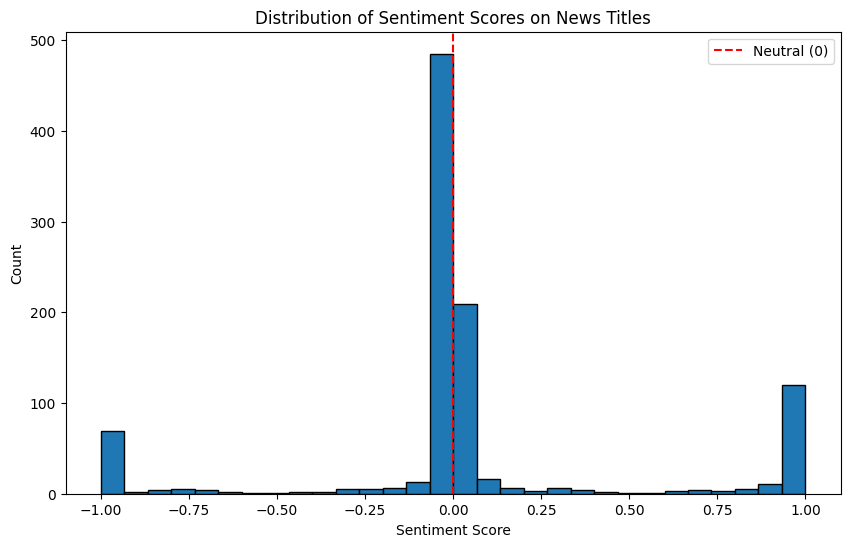


最正面样本:
  Score: 1.000 | Chegg shares are trading higher after Morgan Stanley reinsta
  Score: 1.000 |  Canacol Energy Ltd. Announces 227% Increase in Revenues and
  Score: 1.000 | Medical Marijuana Inc. in a Strong Market Position with Amen
  Score: 1.000 | SolidFire Broadens Market Reach Delivering New Scale-Out All
  Score: 1.000 | Nokia (NOK) Earnings and Revenues Surpass Estimates in Q4

最负面样本:
  Score: -1.000 | UPDATE 2-Cenovus slows Foster Creek expansion; earnings disa
  Score: -1.000 | Pentair plc. Ordinary Share Lowers FY2019 EPS Guidance from 
  Score: -1.000 | TEX-S&P;: 3 most stressed sectors hurt by slow recovery
  Score: -1.000 | Fitch: UK Non-Life London Market Insurance Continues to Face
  Score: -1.000 | Consumer confidence lowest since Katrina

模型不确定性:
  平均不确定性: 0.247
  高不确定性样本(>0.5): 242 条


In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("FNSPID_1000_predictions_corrected.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")

In [41]:
# import torch
# from transformers import BertTokenizer, BertForSequenceClassification

# # 加载模型
# tokenizer = BertTokenizer.from_pretrained("./finbert_model")
# model = BertForSequenceClassification.from_pretrained("./finbert_model")
# model.eval()

# 查看标签映射
print("标签映射:", model.config.id2label)

# 测试
test_texts = [
    "Apple stock price increased sharply today",  # 应该是正面
    "The company reported a significant loss",   # 应该是负面
    "Market remains stable"                      # 应该是中性
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()} 
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 正确解析
    neu = probs[0][0].item()  # Neutral
    pos = probs[0][1].item()  # Positive
    neg = probs[0][2].item()  # Negative
    score = pos - neg
    
    print(f"\n文本: {text}")
    print(f"  中性: {neu:.3f}, 正面: {pos:.3f}, 负面: {neg:.3f}")
    print(f"  情感分数: {score:.3f}")
    
    if score > 0.2:
        print(f"  预测: positive")
    elif score < -0.2:
        print(f"  预测: negative")
    else:
        print(f"  预测: neutral")

标签映射: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}

文本: Apple stock price increased sharply today
  中性: 0.000, 正面: 1.000, 负面: 0.000
  情感分数: 1.000
  预测: positive

文本: The company reported a significant loss
  中性: 0.000, 正面: 0.000, 负面: 1.000
  情感分数: -1.000
  预测: negative

文本: Market remains stable
  中性: 0.000, 正面: 1.000, 负面: 0.000
  情感分数: 1.000
  预测: positive


In [43]:
# 重新测试稳定市场
text = "Market remains stable with no major changes"
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
inputs = {k: v.to(device) for k, v in inputs.items()} 


with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

neu = probs[0][0].item()
pos = probs[0][1].item()
neg = probs[0][2].item()
score = pos - neg

print(f"中性: {neu:.3f}, 正面: {pos:.3f}, 负面: {neg:.3f}")
print(f"分数: {score:.3f}")

中性: 0.520, 正面: 0.477, 负面: 0.003
分数: 0.474


使用new-bbc数据

In [14]:
df = pd.read_csv("bbc_data/bbc_news.csv")

print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"总样本数: {len(df)}")
print(df.head(5))


原始数据形状: (42115, 5)
列名: ['title', 'pubDate', 'guid', 'link', 'description']
总样本数: 42115
                                               title  \
0  Ukraine: Angry Zelensky vows to punish Russian...   
1  War in Ukraine: Taking cover in a town under a...   
2         Ukraine war 'catastrophic for global food'   
3  Manchester Arena bombing: Saffie Roussos's par...   
4  Ukraine conflict: Oil price soars to highest l...   

                         pubDate  \
0  Mon, 07 Mar 2022 08:01:56 GMT   
1  Sun, 06 Mar 2022 22:49:58 GMT   
2  Mon, 07 Mar 2022 00:14:42 GMT   
3  Mon, 07 Mar 2022 00:05:40 GMT   
4  Mon, 07 Mar 2022 08:15:53 GMT   

                                               guid  \
0  https://www.bbc.co.uk/news/world-europe-60638042   
1  https://www.bbc.co.uk/news/world-europe-60641873   
2      https://www.bbc.co.uk/news/business-60623941   
3            https://www.bbc.co.uk/news/uk-60579079   
4      https://www.bbc.co.uk/news/business-60642786   

                            

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os

def extract_and_predict():
    """
    从测试集抽取1000条有效样本并进行FinBERT预测
    """
    
    print("="*60)
    print("Step 1: 读取测试集并抽取样本")
    print("="*60)
    
    # 读取测试集（只读取需要的列以节省内存）
    # bbc
    usecols = ['title', 'pubDate', 'guid', 'link', 'description']

    # fnspid
    usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']
    
    print("正在读取测试集...")
    df = pd.read_csv("FNSPID_data/test.csv", usecols=usecols)
    print(f"总样本数: {len(df):,}")
    
    # 过滤出有标题的行（所有行都有，但确保安全）
    valid_df = df[df['Article_title'].notna()].copy()
    print(f"有效样本数: {len(valid_df):,}")
    
    # 随机抽取1000条
    sample_size = 1000
    sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f"抽取样本数: {len(sampled_df)}")
    
    # 保存抽取的样本
    sample_path = "FNSPID_data/test_sample_1000.csv"
    sampled_df.to_csv(sample_path, index=False)
    print(f"样本已保存到: {sample_path}")
    
    print("\n" + "="*60)
    print("Step 2: 加载 FinBERT 模型")
    print("="*60)
    
    # 加载模型
    model_name = "yiyanghkust/finbert-tone"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    
    # 使用GPU（如果可用）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    print(f"使用设备: {device}")
    
    print("\n" + "="*60)
    print("Step 3: 批量预测情感")
    print("="*60)
    
    # 准备文本
    texts = sampled_df['Article_title'].fillna('').tolist()
    
    # 批量预测
    batch_size = 64
    results = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
        batch_texts = texts[i:i+batch_size]
        
        # 编码
        inputs = tokenizer(batch_texts, return_tensors="pt", 
                          truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 预测
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
        
        # 解析结果
        for j, prob in enumerate(probs):
            neg = prob[0].item()
            neu = prob[1].item()
            pos = prob[2].item()
            score = pos - neg  # 情感分数 -1 到 1
            
            # 分类标签（阈值可调整）
            if score > 0.2:
                label = "positive"
            elif score < -0.2:
                label = "negative"
            else:
                label = "neutral"
            
            results.append({
                'sentiment_score': score,
                'predicted_label': label,
                'negative_prob': neg,
                'neutral_prob': neu,
                'positive_prob': pos
            })
    
    # 合并结果
    result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)
    
    print("\n" + "="*60)
    print("Step 4: 结果分析")
    print("="*60)
    
    # 统计分析
    print(f"\n情感分数统计:")
    print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
    print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
    print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
    print(f"  最大值: {result_df['sentiment_score'].max():.4f}")
    
    print(f"\n情感标签分布:")
    label_counts = result_df['predicted_label'].value_counts()
    for label, count in label_counts.items():
        print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")
    
    # 按股票代码统计（如果有股票代码）
    if result_df['Stock_symbol'].notna().any():
        print(f"\n按股票代码的情感分布 (Top 10):")
        stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
        stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
        print(stock_stats.head(10))
    else:
        print(f"\n注意: 抽取的样本中没有股票代码信息")
    
    # 保存完整结果
    output_path = "FNSPID_1000_predictions.csv"
    result_df.to_csv(output_path, index=False)
    print(f"\n✅ 预测结果已保存到: {output_path}")
    print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")
    
    print("\n" + "="*60)
    print("Step 5: 高置信度样本展示（供人工验证）")
    print("="*60)
    
    # 展示高置信度样本
    high_conf = result_df[
        (result_df['negative_prob'] > 0.8) | 
        (result_df['positive_prob'] > 0.8)
    ].head(10)
    
    if len(high_conf) > 0:
        for idx, row in high_conf.iterrows():
            print(f"\n样本 {idx+1}:")
            print(f"  日期: {row['Date']}")
            print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
            print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
            print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
            print(f"  标题: {row['Article_title'][:150]}...")
    else:
        print("没有找到高置信度样本")
    
    # 展示边界样本（中性）
    print("\n" + "="*60)
    print("边界样本（中性/低置信度）:")
    print("="*60)
    neutral_samples = result_df[
        (result_df['sentiment_score'] > -0.1) & 
        (result_df['sentiment_score'] < 0.1)
    ].head(5)
    
    for idx, row in neutral_samples.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  标题: {row['Article_title'][:100]}...")
        print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")
    
    return result_df

# 运行
if __name__ == "__main__":
    results = extract_and_predict()

In [15]:

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
# bbc
usecols = ['title', 'pubDate', 'guid', 'link', 'description']

# fnspid
# usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("bbc_data/bbc_news.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "bbc_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")


Step 1: 读取测试集并抽取样本
正在读取测试集...
总样本数: 42,115
有效样本数: 42,115
抽取样本数: 1000
样本已保存到: bbc_data/test_sample_1000.csv


In [17]:

print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)

# 加载模型


import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "./finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][0].item()
    neu = probs[0][1].item()
    pos = probs[0][2].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")

print("\n✅ 模型工作正常!")



# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")



Step 2: 加载 FinBERT 模型
从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./finbert_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on yo

   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.305, 中性: 0.290, 正向: 0.404
   情感分数: 0.099
   预测: neutral

   文本: The company reported a significant loss this quart...
   负向: 0.301, 中性: 0.298, 正向: 0.401
   情感分数: 0.100
   预测: neutral

   文本: Market remains stable with no major changes...
   负向: 0.297, 中性: 0.297, 正向: 0.406
   情感分数: 0.109
   预测: neutral

✅ 模型工作正常!
使用设备: cuda


In [18]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        neg = prob[0].item()
        neu = prob[1].item()
        pos = prob[2].item()
        score = pos - neg  # 情感分数 -1 到 1
        
        # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        if score > 0.05:  # 原来是 0.2
            label = "positive"
        elif score < -0.05:  # 原来是 -0.2
            label = "negative"
        else:
            label = "neutral"
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 16/16 [00:01<00:00, 15.77it/s]


In [20]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['pubDate'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['pubDate'].notna()].groupby('pubDate')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "bbc_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['pubDate'] if pd.notna(row['pubDate']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")



Step 4: 结果分析

情感分数统计:
  均值: 0.0787
  标准差: 0.0265
  最小值: -0.0294
  最大值: 0.1258

情感标签分布:
  positive: 843 (84.3%)
  neutral: 157 (15.7%)

按股票代码的情感分布 (Top 10):
                                   mean  count
pubDate                                       
Wed, 10 May 2023 23:43:51 GMT  0.010574      2

✅ 预测结果已保存到: bbc_1000_predictions.csv
   文件大小: 0.39 MB

Step 5: 高置信度样本展示（供人工验证）
没有找到高置信度样本

边界样本（中性/低置信度）:

样本 1:
  标题: US's only Palestinian-American Congresswoman censured over comments...
  分数: 0.092 (负=0.31, 中=0.30, 正=0.40)

样本 3:
  标题: Cleared pony owner criticises 'trial by social media'...
  分数: 0.090 (负=0.31, 中=0.29, 正=0.40)

样本 4:
  标题: Wrexham: Can football fame make City of Culture vulture?...
  分数: 0.033 (负=0.33, 中=0.31, 正=0.36)

样本 5:
  标题: Gaza ceasefire talks intensify in Cairo...
  分数: 0.072 (负=0.32, 中=0.29, 正=0.39)

样本 6:
  标题: Bud Light boycott over trans influencer Dylan Mulvaney hits beer giant's sales...
  分数: 0.090 (负=0.31, 中=0.29, 正=0.40)


情感分数分布:
count    1000.000000
mean        0.078684
std         0.026538
min        -0.029393
25%         0.063170
50%         0.084982
75%         0.099144
max         0.125787
Name: sentiment_score, dtype: float64


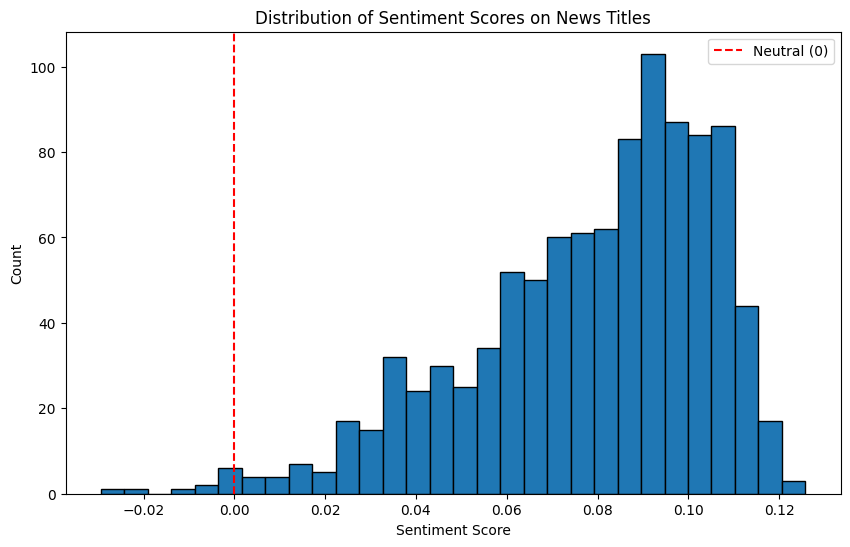


最正面样本:
  Score: 0.126 | Interest rates cut... but don't expect more straight away
  Score: 0.122 | 'I think we can do it' - Dyche confident of Everton escape
  Score: 0.121 | Mother and baby home compensation cut off 'insulting'
  Score: 0.120 | 'Amazed if City don't spend' - but youngsters can ease Alvar
  Score: 0.119 | Are taxes going up or down?

最负面样本:
  Score: -0.029 | Sweden's returning champion, Loreen. Eurovision Q&A
  Score: -0.022 | Teri Garr, Young Frankenstein and Tootsie star, dies at 79
  Score: -0.013 | Six women arrested after boy, one, dies at Dudley nursery
  Score: -0.006 | Face of 75,000-year-old Neanderthal woman revealed
  Score: -0.004 | Natasha Jonas: Liverpool fighter becomes two-weight world ch

模型不确定性:
  平均不确定性: 0.710
  高不确定性样本(>0.5): 1000 条


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("bbc_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")

In [23]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 使用 Auto 类，它会自动处理
local_model_path = "./finbert_model"
tokenizer = AutoTokenizer.from_pretrained(local_model_path)
model = AutoModelForSequenceClassification.from_pretrained(local_model_path)

print("✅ 模型加载成功")
print(f"模型类型: {type(model)}")
print(f"分类头: {model.classifier}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./finbert_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on yo

✅ 模型加载成功
模型类型: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>
分类头: Linear(in_features=768, out_features=3, bias=True)


In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os
import shutil

# 清理旧模型
local_model_path = "./finbert_model"
if os.path.exists(local_model_path):
    shutil.rmtree(local_model_path)

# 重新下载正确的模型
model_name = "yiyanghkust/finbert-tone"
print("重新下载正确的 FinBERT 模型...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 保存到本地
model.save_pretrained(local_model_path)
tokenizer.save_pretrained(local_model_path)

print(f"✅ 模型已正确保存到: {local_model_path}")

重新下载正确的 FinBERT 模型...


ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

# FinBERT Example Notebook

This notebooks shows how to train and use the FinBERT pre-trained language model for financial sentiment analysis.

## Modules 

In [1]:
from pathlib import Path
import shutil
import os
import logging
import sys
sys.path.append('..')

from textblob import TextBlob
from pprint import pprint
from sklearn.metrics import classification_report

from transformers import AutoModelForSequenceClassification

from finbert.finbert import *
import finbert.utils as tools

%load_ext autoreload
%autoreload 2

project_dir = Path.cwd().parent
pd.set_option('max_colwidth', -1)

In [2]:
logging.basicConfig(format = '%(asctime)s - %(levelname)s - %(name)s -   %(message)s',
                    datefmt = '%m/%d/%Y %H:%M:%S',
                    level = logging.ERROR)

## Prepare the model

### Setting path variables:
1. `lm_path`: the path for the pre-trained language model (If vanilla Bert is used then no need to set this one).
2. `cl_path`: the path where the classification model is saved.
3. `cl_data_path`: the path of the directory that contains the data files of `train.csv`, `validation.csv`, `test.csv`.
---

In the initialization of `bertmodel`, we can either use the original pre-trained weights from Google by giving `bm = 'bert-base-uncased`, or our further pre-trained language model by `bm = lm_path`


---
All of the configurations with the model is controlled with the `config` variable. 

In [3]:
lm_path = project_dir/'models'/'language_model'/'finbertTRC2'
cl_path = project_dir/'models'/'classifier_model'/'finbert-sentiment'
cl_data_path = project_dir/'data'/'sentiment_data'

###  Configuring training parameters

You can find the explanations of the training parameters in the class docsctrings. 

In [4]:
# Clean the cl_path
try:
    shutil.rmtree(cl_path) 
except:
    pass

bertmodel = AutoModelForSequenceClassification.from_pretrained(lm_path,cache_dir=None, num_labels=3)


config = Config(   data_dir=cl_data_path,
                   bert_model=bertmodel,
                   num_train_epochs=4,
                   model_dir=cl_path,
                   max_seq_length = 48,
                   train_batch_size = 32,
                   learning_rate = 2e-5,
                   output_mode='classification',
                   warm_up_proportion=0.2,
                   local_rank=-1,
                   discriminate=True,
                   gradual_unfreeze=True)

Some weights of the model checkpoint at /home/ubuntu/finbert/models/language_model/finbertTRC2 were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not ini

`finbert` is our main class that encapsulates all the functionality. The list of class labels should be given in the prepare_model method call with label_list parameter.

In [5]:
finbert = FinBert(config)
finbert.base_model = 'bert-base-uncased'
finbert.config.discriminate=True
finbert.config.gradual_unfreeze=True

In [6]:
finbert.prepare_model(label_list=['positive','negative','neutral'])

12/24/2020 12:45:20 - INFO - finbert.finbert -   device: cuda n_gpu: 1, distributed training: False, 16-bits training: False


## Fine-tune the model

In [7]:
# Get the training examples
train_data = finbert.get_data('train')

In [8]:
model = finbert.create_the_model()

### [Optional] Fine-tune only a subset of the model
The variable `freeze` determines the last layer (out of 12) to be freezed. You can skip this part if you want to fine-tune the whole model.

<span style="color:red">Important: </span>
Execute this step if you want a shorter training time in the expense of accuracy.

In [9]:
# This is for fine-tuning a subset of the model.

freeze = 6

for param in model.bert.embeddings.parameters():
    param.requires_grad = False
    
for i in range(freeze):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

### Training

In [10]:
trained_model = finbert.train(train_examples = train_data, model = model)

12/24/2020 12:45:23 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:45:23 - INFO - finbert.utils -   guid: train-1
12/24/2020 12:45:23 - INFO - finbert.utils -   tokens: [CLS] after the reporting period , bio ##tie north american licensing partner so ##max ##on pharmaceuticals announced positive results with na ##lm ##efe ##ne in a pilot phase 2 clinical trial for smoking ce ##ssa ##tion [SEP]
12/24/2020 12:45:23 - INFO - finbert.utils -   input_ids: 101 2044 1996 7316 2558 1010 16012 9515 2167 2137 13202 4256 2061 17848 2239 24797 2623 3893 3463 2007 6583 13728 27235 2638 1999 1037 4405 4403 1016 6612 3979 2005 9422 8292 11488 3508 102 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:23 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:23 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/

12/24/2020 12:45:28 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:45:28 - INFO - finbert.utils -   guid: validation-1
12/24/2020 12:45:28 - INFO - finbert.utils -   tokens: [CLS] our in - depth expertise extends to the fields of energy , industry , urban & mobility and water & environment [SEP]
12/24/2020 12:45:28 - INFO - finbert.utils -   input_ids: 101 2256 1999 1011 5995 11532 8908 2000 1996 4249 1997 2943 1010 3068 1010 3923 1004 12969 1998 2300 1004 4044 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:28 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:28 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:28 - INFO - finbert.utils -   label: neutral (id = 2)
12/24/2020 12:45:28 - INFO - finbert.finbert -   ***** Loading data *****
12/24/2


Validation losses: [0.8303732826159551]
No best model found



Epoch:  25%|██▌       | 1/4 [00:05<00:16,  5.65s/it]

12/24/2020 12:45:37 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:45:37 - INFO - finbert.utils -   guid: validation-1
12/24/2020 12:45:37 - INFO - finbert.utils -   tokens: [CLS] our in - depth expertise extends to the fields of energy , industry , urban & mobility and water & environment [SEP]
12/24/2020 12:45:37 - INFO - finbert.utils -   input_ids: 101 2256 1999 1011 5995 11532 8908 2000 1996 4249 1997 2943 1010 3068 1010 3923 1004 12969 1998 2300 1004 4044 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:37 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:37 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:45:37 - INFO - finbert.utils -   label: neutral (id = 2)
12/24/2020 12:45:38 - INFO - finbert.finbert -   ***** Loading data *****
12/24/2

...


Validation losses: [0.8303732826159551, 0.4003512469621805, 0.3436752695303697]



Epoch:  75%|███████▌  | 3/4 [00:27<00:08,  8.47s/it]

12/24/2020 12:46:04 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:46:04 - INFO - finbert.utils -   guid: validation-1
12/24/2020 12:46:04 - INFO - finbert.utils -   tokens: [CLS] our in - depth expertise extends to the fields of energy , industry , urban & mobility and water & environment [SEP]
12/24/2020 12:46:04 - INFO - finbert.utils -   input_ids: 101 2256 1999 1011 5995 11532 8908 2000 1996 4249 1997 2943 1010 3068 1010 3923 1004 12969 1998 2300 1004 4044 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:04 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:04 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:04 - INFO - finbert.utils -   label: neutral (id = 2)
12/24/2020 12:46:04 - INFO - finbert.finbert -   ***** Loading data *****
12/24/2

Epoch: 100%|██████████| 4/4 [00:40<00:00, 10.20s/it]


Validation losses: [0.8303732826159551, 0.4003512469621805, 0.3436752695303697, 0.34499044028612286]


## Test the model

`bert.evaluate` outputs the DataFrame, where true labels and logit values for each example is given

In [11]:
test_data = finbert.get_data('test')

In [12]:
results = finbert.evaluate(examples=test_data, model=trained_model)

12/24/2020 12:46:05 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:46:05 - INFO - finbert.utils -   guid: test-1
12/24/2020 12:46:05 - INFO - finbert.utils -   tokens: [CLS] the bristol port company has sealed a one million pound contract with cooper specialised handling to supply it with four 45 - ton ##ne , custom ##ised reach stack ##ers from ko ##ne ##cr ##ane ##s [SEP]
12/24/2020 12:46:05 - INFO - finbert.utils -   input_ids: 101 1996 7067 3417 2194 2038 10203 1037 2028 2454 9044 3206 2007 6201 17009 8304 2000 4425 2009 2007 2176 3429 1011 10228 2638 1010 7661 5084 3362 9991 2545 2013 12849 2638 26775 7231 2015 102 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:05 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:05 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:05 - IN

### Prepare the classification report

In [13]:
def report(df, cols=['label','prediction','logits']):
    #print('Validation loss:{0:.2f}'.format(metrics['best_validation_loss']))
    cs = CrossEntropyLoss(weight=finbert.class_weights)
    loss = cs(torch.tensor(list(df[cols[2]])),torch.tensor(list(df[cols[0]])))
    print("Loss:{0:.2f}".format(loss))
    print("Accuracy:{0:.2f}".format((df[cols[0]] == df[cols[1]]).sum() / df.shape[0]) )
    print("\nClassification Report:")
    print(classification_report(df[cols[0]], df[cols[1]]))

In [14]:
results['prediction'] = results.predictions.apply(lambda x: np.argmax(x,axis=0))

In [15]:
report(results,cols=['labels','prediction','predictions'])

Loss:0.39
Accuracy:0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.78       267
           1       0.78      0.89      0.83       128
           2       0.92      0.80      0.85       575

    accuracy                           0.83       970
   macro avg       0.80      0.85      0.82       970
weighted avg       0.84      0.83      0.83       970



### Get predictions

With the `predict` function, given a piece of text, we split it into a list of sentences and then predict sentiment for each sentence. The output is written into a dataframe. Predictions are represented in three different columns: 

1) `logit`: probabilities for each class

2) `prediction`: predicted label

3) `sentiment_score`: sentiment score calculated as: probability of positive - probability of negative

Below we analyze a paragraph taken out of [this](https://www.economist.com/finance-and-economics/2019/01/03/a-profit-warning-from-apple-jolts-markets) article from The Economist. For comparison purposes, we also put the sentiments predicted with TextBlob.
> Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened. The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. Yields on government bonds fell as investors fled to the traditional haven in a market storm.

In [16]:
text = "Later that day Apple said it was revising down its earnings expectations in \
the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. \
The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours \
trading and the decline was extended to more than 10% when the market opened. The dollar fell \
by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering \
some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. \
Yields on government bonds fell as investors fled to the traditional haven in a market storm."

In [17]:
cl_path = project_dir/'models'/'classifier_model'/'finbert-sentiment'
model = AutoModelForSequenceClassification.from_pretrained(cl_path, cache_dir=None, num_labels=3)

In [18]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
result = predict(text,model)

12/24/2020 12:46:11 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:46:11 - INFO - finbert.utils -   guid: 0
12/24/2020 12:46:11 - INFO - finbert.utils -   tokens: [CLS] later that day apple said it was rev ##ising down its earnings expectations in the fourth quarter of 2018 , largely because of lower sales and signs of economic weakness in china . [SEP]
12/24/2020 12:46:11 - INFO - finbert.utils -   input_ids: 101 2101 2008 2154 6207 2056 2009 2001 7065 9355 2091 2049 16565 10908 1999 1996 2959 4284 1997 2760 1010 4321 2138 1997 2896 4341 1998 5751 1997 3171 11251 1999 2859 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:11 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:11 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [20]:
blob = TextBlob(text)
result['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]
result

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,"Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China.","[0.014240683, 0.9723466, 0.013412752]",negative,-0.958106,0.051746
1,The news rapidly infected financial markets.,"[0.05297577, 0.9000978, 0.046926454]",negative,-0.847122,0.000000
2,Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened.,"[0.013397858, 0.9760023, 0.010599791]",negative,-0.962604,0.500000
3,"The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground.","[0.091838144, 0.89670366, 0.011458234]",negative,-0.804866,0.000000
4,Asian stockmarkets closed down on January 3rd and European ones opened lower.,"[0.011584295, 0.9757397, 0.012676031]",negative,-0.964155,-0.051111
5,Yields on government bonds fell as investors fled to the traditional haven in a market storm.,"[0.0301131, 0.95474213, 0.015144793]",negative,-0.924629,0.000000


In [21]:
print(f'Average sentiment is %.2f.' % (result.sentiment_score.mean()))

Average sentiment is -0.91.


Here is another example

In [22]:
text2 = "Shares in the spin-off of South African e-commerce group Naspers surged more than 25% \
in the first minutes of their market debut in Amsterdam on Wednesday. Bob van Dijk, CEO of \
Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the \
Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019. REUTERS/Piroschka van de Wouw \
Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a \
31% stake in Chinese tech titan Tencent. There is 'way more demand than is even available, so that’s \
good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg. 'It’s going to be an interesting \
hour of trade after opening this morning.' Euronext had given an indicative price of 58.70 euros \
per share for Prosus, implying a market value of 95.3 billion euros ($105 billion). The shares \
jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT."

In [23]:
result2 = predict(text2,model)
blob = TextBlob(text2)
result2['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]

12/24/2020 12:46:11 - INFO - finbert.utils -   *** Example ***
12/24/2020 12:46:11 - INFO - finbert.utils -   guid: 0
12/24/2020 12:46:11 - INFO - finbert.utils -   tokens: [CLS] shares in the spin - off of south african e - commerce group nas ##pers surged more than 25 % in the first minutes of their market debut in amsterdam on wednesday . [SEP]
12/24/2020 12:46:11 - INFO - finbert.utils -   input_ids: 101 6661 1999 1996 6714 1011 2125 1997 2148 3060 1041 1011 6236 2177 17235 7347 18852 2062 2084 2423 1003 1999 1996 2034 2781 1997 2037 3006 2834 1999 7598 2006 9317 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:11 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2020 12:46:11 - INFO - finbert.utils -   token_type_ids: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [24]:
result2

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,Shares in the spin-off of South African e-commerce group Naspers surged more than 25% in the first minutes of their market debut in Amsterdam on Wednesday.,"[0.93336153, 0.020355493, 0.046283066]",positive,0.913006,0.250000
1,"Bob van Dijk, CEO of Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019.","[0.043918967, 0.009017709, 0.9470634]",neutral,0.034901,0.000000
2,"REUTERS/Piroschka van de Wouw Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a 31% stake in Chinese tech titan Tencent.","[0.16799231, 0.008004095, 0.8240036]",neutral,0.159988,0.000000
3,"There is 'way more demand than is even available, so that’s good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg.","[0.9162205, 0.013223126, 0.07055632]",positive,0.902997,0.533333
4,'It’s going to be an interesting hour of trade after opening this morning.',"[0.65132874, 0.03364602, 0.3150252]",positive,0.617683,0.500000
5,"Euronext had given an indicative price of 58.70 euros per share for Prosus, implying a market value of 95.3 billion euros ($105 billion).","[0.1687288, 0.012589393, 0.81868184]",neutral,0.156139,0.000000
6,The shares jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT.,"[0.8279447, 0.011943376, 0.16011195]",positive,0.816001,0.000000


In [25]:
print(f'Average sentiment is %.2f.' % (result2.sentiment_score.mean()))

Average sentiment is 0.51.
